# Notebook 01 — Packet Counter Reconstruction
**Thesis §4.2, §5.1–5.2** | produces `data/reconstructed.csv`

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path('../../data')
RAW_CSV  = DATA_DIR / 'cleaned_dataset_Obiri_2025.csv'
OUT_CSV  = DATA_DIR / 'reconstructed.csv'

## 1 · Load & Sort
Parse UTC timestamps and sort per device — InfluxDB export order is not guaranteed.

In [11]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} → {df["time"].max().date()}')

Rows    : 1,217,313
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-09-26 → 2025-05-22


## 2 · Reconstruction  *(Definition 1, §4.2)*
$$\ell_i = \max(c_{i+1} - c_i - 1,\; 0)$$
New columns: `loss`, `is_reset`, `total_tx`

In [13]:
def reconstruct(grp):
    grp = grp.copy().reset_index(drop=True)

    delta_f = grp['f_count'].diff()    # MAC-layer gap → radio losses
    delta_p = grp['p_count'].diff()    # app-layer gap → total losses

    is_reset = delta_f < 0             # negative gap → device reboot

    # Definition 1 §4.2: ℓ = max(Δf − 1, 0)
    loss_f = (delta_f - 1).clip(lower=0)
    loss_f[is_reset] = 0               # loss unknown at reboot
    loss_f.iloc[0]   = 0               # no prior interval

    # app-to-MAC drops: packets lost before reaching the radio
    loss_internal = (delta_p - delta_f).clip(lower=0)
    loss_internal[is_reset] = 0
    loss_internal.iloc[0]   = 0

    grp['loss']          = loss_f.astype(int)                   # radio losses (primary)
    grp['internal_loss'] = loss_internal.astype(int)            # app-to-MAC drops (future work)
    grp['total_loss']    = (loss_f + loss_internal).astype(int) # p_count equivalent (validation)
    grp['is_reset']      = is_reset.fillna(False)               # reboot flag
    grp['total_tx']      = 1 + grp['loss']                      # total TX attempts per interval
    return grp

df = df.groupby('device_id', group_keys=False).apply(reconstruct)
print('Reconstruction done.')

print(f'Devices : {sorted(df["device_id"].unique())}')

KeyError: 'device_id'

In [6]:
import pandas as pd
print(pd.__version__)

3.0.2


## 3 · Verification  *(Table 7.1)*
Check these numbers match the expected values in your thesis.

In [38]:
print(f"{'Device':<8} {'Dist(m)':^8} {'C.Walls':^8} {'W.Walls':^8} {'Received':^10} {'Recon.Lost':^12} {'Total TX':^10} {'PDR%':^8} {'Resets':^7}")
print('-' * 90)
total_rx = total_lost = 0
for dev, g in df.groupby('device_id'):
    rx     = len(g)
    lost   = int(g['loss'].sum())
    total_rx   += rx
    total_lost += lost
    pdr    = rx / (rx + lost) * 100
    resets = int(g['is_reset'].sum())
    dist   = int(g['distance'].iloc[0])
    cwalls = int(g['c_walls'].iloc[0])
    wwalls = int(g['w_walls'].iloc[0])
    print(f"{dev:<8} {dist:^8} {cwalls:^8} {wwalls:^8} {rx:^10,} {lost:^12,} {rx+lost:^10,} {pdr:^8.2f} {resets:^7}")
print('-' * 90)
grand = total_rx + total_lost
print(f"{'Total':<8} {'':^8} {'':^8} {'':^8} {total_rx:^10,} {total_lost:^12,} {grand:^10,} {total_rx/grand*100:^8.2f}")

Device   Dist(m)  C.Walls  W.Walls   Received   Recon.Lost   Total TX    PDR%   Resets 
------------------------------------------------------------------------------------------
ED0         10       0        0      202,249     106,064     308,313    65.60      4   
ED1         8        1        0      201,302     106,029     307,331    65.50      1   
ED2         23       0        2      204,033     104,184     308,217    66.20      1   
ED3         18       1        2      200,549     105,950     306,499    65.43      3   
ED4         37       0        5      200,112     105,131     305,243    65.56      1   
ED5         40       2        2      209,068     104,580     313,648    66.66      4   
------------------------------------------------------------------------------------------
Total                               1,217,313    631,938    1,849,251   65.83  


In [15]:
print(df.columns.tolist())
print(df[['loss']].describe())

['time', 'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'rssi', 'snr', 'SF', 'frequency', 'f_count', 'p_count', 'toa', 'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power', 'esp', 'loss', 'internal_loss', 'total_loss', 'is_reset', 'total_tx']
               loss
count  1.217313e+06
mean   5.191253e-01
std    2.499790e+01
min    0.000000e+00
25%    0.000000e+00
50%    0.000000e+00
75%    0.000000e+00
max    1.106000e+04


## 4 · p_count vs f_count Divergence  *(Table 5.2)*
`p_count` increments on every TX attempt; `f_count` only on reception.  
Divergence ≈ cumulative loss — independent cross-check.

In [ ]:
div = df.groupby('device_id').agg(
    p_min=('p_count','min'), p_max=('p_count','max'),
    f_min=('f_count','min'), f_max=('f_count','max'),
).reset_index()
div['p_range']    = div['p_max'] - div['p_min']
div['f_range']    = div['f_max'] - div['f_min']
div['divergence'] = div['p_range'] - div['f_range']
div['pct']        = (div['divergence'] / div['p_range'] * 100).round(1)
div[['device_id','p_range','f_range','divergence','pct']]

Large Gap Test

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# get all non-zero loss intervals
losses = df[df['loss'] > 0]['loss']

print("Loss distribution summary:")
print(losses.describe())
print(f"\nPercentiles:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f"  {p}th percentile: {losses.quantile(p/100):.0f}")

print(f"\nLoss value counts (top 20):")
print(losses.value_counts().head(20).sort_index())

# show the gap clearly
loss_counts = losses.value_counts().sort_index()
radio = loss_counts[loss_counts.index <= 35]
print("Losses 1-35 (radio zone):")
print(radio.to_string())
print(f"\nLosses > 35: {len(losses[losses > 35])} intervals")
print(f"Losses > 60: {len(losses[losses > 60])} intervals")
print(f"Losses > 36: {len(losses[losses > 36])} intervals")




Loss distribution summary:
count    82270.000000
mean         7.681269
std         95.871728
min          1.000000
25%          5.000000
50%          8.000000
75%          8.000000
max      11060.000000
Name: loss, dtype: float64

Percentiles:
  50th percentile: 8
  75th percentile: 8
  90th percentile: 8
  95th percentile: 8
  99th percentile: 9
  99.5th percentile: 11
  99.9th percentile: 81

Loss value counts (top 20):
loss
1     15025
2      3125
3      1225
4       904
5       853
6      1224
7      3040
8     53349
9      2886
10      210
11       59
12       25
13       28
14       16
15       12
16        7
17       12
19        9
36       19
37       15
Name: count, dtype: int64
Losses 1-35 (radio zone):
loss
1     15025
2      3125
3      1225
4       904
5       853
6      1224
7      3040
8     53349
9      2886
10      210
11       59
12       25
13       28
14       16
15       12
16        7
17       12
18        3
19        9
20        4
21        6
22        6
23      

CHECK FOR INFRASTRUCTURE OUTAGE!!!!!!!!!!

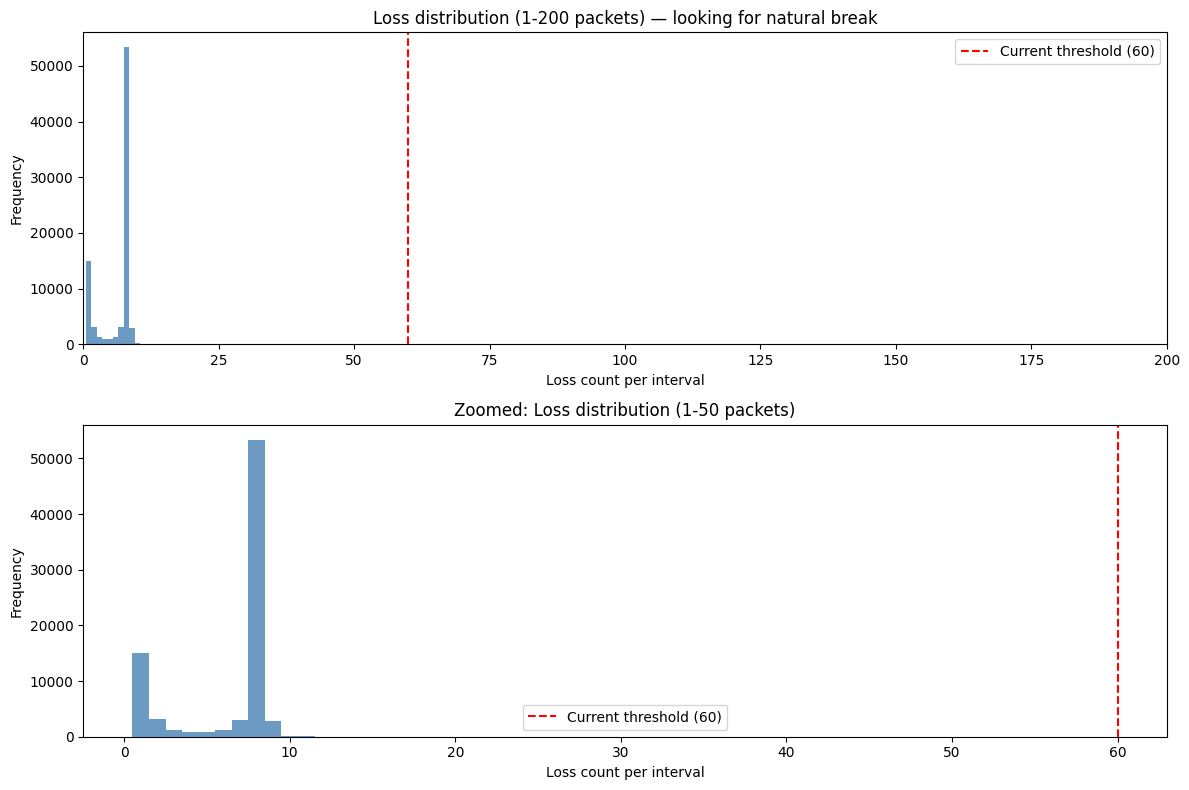

Figure saved.

Loss values 10-100 — looking for the natural gap:
loss
1     15025
2      3125
3      1225
4       904
5       853
6      1224
7      3040
8     53349
9      2886
10      210
11       59
12       25
13       28
14       16
15       12
16        7
17       12
18        3
19        9
20        4
21        6
22        6
23        4
24        6
25        7
26        3
27        4
28        2
29        4
30        7
31        2
32        2
33        2
34        5
35        6
36       19
37       15
38        5
39        6
40        4
41        2
42        6
43        2
44        6
45        3
46        3
47        1
48        5
49        1
50        1
51        1
54        1
55        1
57        3
63        1
64        1
65        2
66        2
67        1
68        1
69        1
70        1
71        2
72        2
74        3
75        2
80        1
82        2
83        1
86        1
89        1
91        1
92        6
97        2
99        1


In [62]:
import matplotlib.pyplot as plt
import numpy as np

losses = df[df['loss'] > 0]['loss']

# focus on the range 1-200 to see the gap clearly
loss_counts = losses[losses <= 200].value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# top plot — full range 1-200
axes[0].bar(loss_counts.index, loss_counts.values,
            color='steelblue', width=1, alpha=0.8)
axes[0].set_xlabel('Loss count per interval')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Loss distribution (1-200 packets) — looking for natural break')
axes[0].set_xlim(0, 200)
axes[0].axvline(x=60, color='red', linewidth=1.5,
                linestyle='--', label='Current threshold (60)')
axes[0].legend()

# bottom plot — zoomed 1-50 to see radio zone clearly
loss_zoom = losses[losses <= 50].value_counts().sort_index()
axes[1].bar(loss_zoom.index, loss_zoom.values,
            color='steelblue', width=1, alpha=0.8)
axes[1].set_xlabel('Loss count per interval')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Zoomed: Loss distribution (1-50 packets)')
axes[1].axvline(x=60, color='red', linewidth=1.5,
                linestyle='--', label='Current threshold (60)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/loss_distribution_threshold.pdf')
plt.savefig('../figures/loss_distribution_threshold.png')
plt.show()
print('Figure saved.')

# also print the exact values around the suspected gap
print("\nLoss values 10-100 — looking for the natural gap:")
mid_range = losses[losses.between(1,100)].value_counts().sort_index()
print(mid_range.to_string())

The natural break is actually at 10, not 60.
Everything above 9 is either:

Ambiguous transition zone (10-35) — very rare, unclear cause
Small recurring spike at 36-37 — suspicious, worth investigating
Confirmed infrastructure outages (60+)

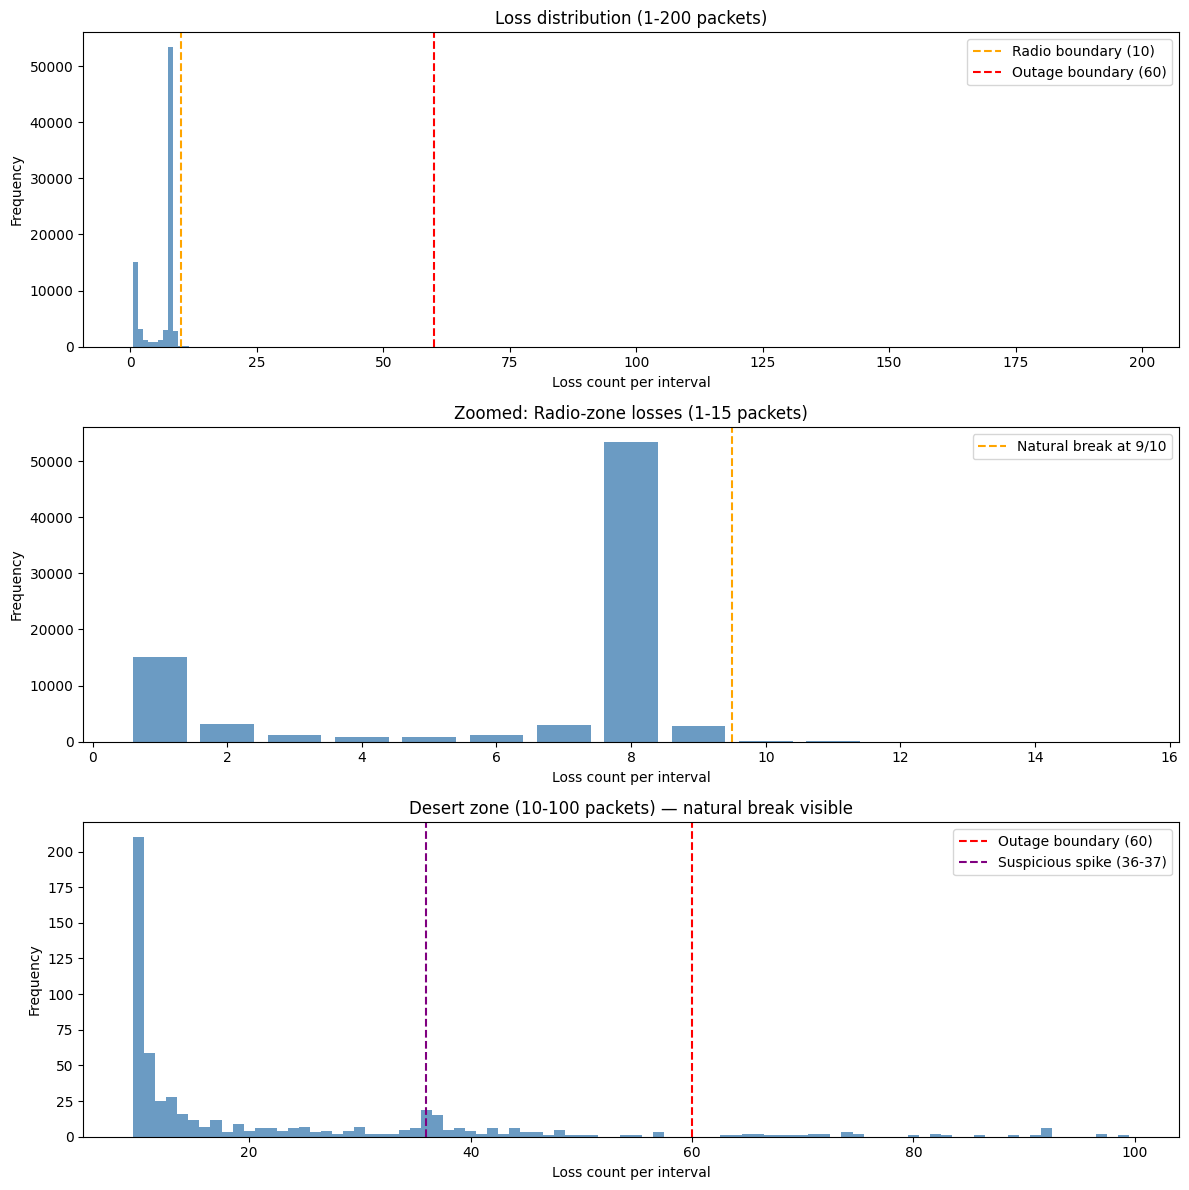

Zone 1 — radio losses (1-9)      : 81,631 intervals
Zone 2 — ambiguous (10-59)        : 536 intervals
Zone 2b — suspicious spike (36-37): 34 intervals
Zone 3 — outages (60+)            : 103 intervals


In [60]:
import matplotlib.pyplot as plt
import numpy as np

losses = df[df['loss'] > 0]['loss']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# plot 1 — full range 1-200
loss_counts = losses[losses <= 200].value_counts().sort_index()
axes[0].bar(loss_counts.index, loss_counts.values,
            color='steelblue', width=1, alpha=0.8)
axes[0].set_xlabel('Loss count per interval')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Loss distribution (1-200 packets)')
axes[0].axvline(x=10, color='orange', linewidth=1.5,
                linestyle='--', label='Radio boundary (10)')
axes[0].axvline(x=60, color='red', linewidth=1.5,
                linestyle='--', label='Outage boundary (60)')
axes[0].legend()

# plot 2 — zoomed 1-15 to see radio zone clearly
loss_zoom = losses[losses <= 15].value_counts().sort_index()
axes[1].bar(loss_zoom.index, loss_zoom.values,
            color='steelblue', width=0.8, alpha=0.8)
axes[1].set_xlabel('Loss count per interval')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Zoomed: Radio-zone losses (1-15 packets)')
axes[1].axvline(x=9.5, color='orange', linewidth=1.5,
                linestyle='--', label='Natural break at 9/10')
axes[1].legend()

# plot 3 — desert zone 10-100
loss_desert = losses[losses.between(10,100)].value_counts().sort_index()
axes[2].bar(loss_desert.index, loss_desert.values,
            color='steelblue', width=1, alpha=0.8)
axes[2].set_xlabel('Loss count per interval')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Desert zone (10-100 packets) — natural break visible')
axes[2].axvline(x=60, color='red', linewidth=1.5,
                linestyle='--', label='Outage boundary (60)')
axes[2].axvline(x=36, color='purple', linewidth=1.5,
                linestyle='--', label='Suspicious spike (36-37)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../figures/loss_distribution_threshold.pdf')
plt.savefig('../figures/loss_distribution_threshold.png')
plt.show()

# count what falls in each zone
print(f"Zone 1 — radio losses (1-9)      : {len(losses[losses <= 9]):,} intervals")
print(f"Zone 2 — ambiguous (10-59)        : {len(losses[losses.between(10,59)]):,} intervals")
print(f"Zone 2b — suspicious spike (36-37): {len(losses[losses.between(36,37)]):,} intervals")
print(f"Zone 3 — outages (60+)            : {len(losses[losses >= 60]):,} intervals")

In [61]:
# check every value between 37 and 65
print("Loss values 37-65:")
mid = losses[losses.between(37, 65)].value_counts().sort_index()
print(mid.to_string())

print(f"\nTotal intervals 37-65: {len(losses[losses.between(37,65)])}")
print(f"Total intervals 38-59: {len(losses[losses.between(38,59)])}")
print(f"Total intervals 40-59: {len(losses[losses.between(40,59)])}")

Loss values 37-65:
loss
37    15
38     5
39     6
40     4
41     2
42     6
43     2
44     6
45     3
46     3
47     1
48     5
49     1
50     1
51     1
54     1
55     1
57     3
63     1
64     1
65     2

Total intervals 37-65: 70
Total intervals 38-59: 51
Total intervals 40-59: 40


In [52]:
# check SF distribution for intervals where loss == 8
loss8 = df[df['loss'] == 8]
print("SF distribution when loss = 8:")
print(loss8['SF'].value_counts().sort_index())

print(f"\nTotal loss=8 intervals: {len(loss8):,}")
print(f"As % of all loss intervals: {len(loss8)/len(df[df['loss']>0])*100:.1f}%")

# compare with other loss values
print("\nSF distribution when loss = 1-7:")
print(df[df['loss'].between(1,7)]['SF'].value_counts().sort_index())

SF distribution when loss = 8:
SF
7         6
8        26
9       426
10    52891
Name: count, dtype: int64

Total loss=8 intervals: 53,349
As % of all loss intervals: 64.8%

SF distribution when loss = 1-7:
SF
7     3640
8     5025
9     7972
10    8759
Name: count, dtype: int64


SF10 explains everything.
52,891 out of 53,349 loss=8 intervals are SF10. That is 99.1% of all loss=8 intervals coming from one spreading factor.
The explanation:
Your devices transmit every 60 seconds. At SF10, Time-on-Air is 452ms. The EU868 duty cycle limit is 1% per sub-band. After transmitting at SF10, the device must wait:
wait time=452ms0.01=45.2 seconds\text{wait time} = \frac{452\text{ms}}{0.01} = 45.2\text{ seconds}wait time=0.01452ms​=45.2 seconds
So the device transmits at SF10, then must wait 45 seconds before it can transmit again. It fires again at 60 seconds. That is fine — one packet per minute, within duty cycle.
But here is the key: your dataset shows SF rotates through 7, 8, 9, 10. When the device is assigned SF10, every single transmission takes 452ms of airtime. The duty cycle back-off means the device occasionally cannot transmit when it wants to — the MAC layer blocks it and increments p_count but f_count does not move.
Wait — this means loss=8 at SF10 is actually internal loss, not radio loss.
These 52,891 intervals are duty cycle back-off events — the device was blocked internally, never fired the radio. They should be in internal_loss, not loss

In [54]:
# check internal_loss for loss=8 SF10 intervals
mask = (df['loss'] == 8) & (df['SF'] == 10)
print("For loss=8, SF=10 intervals:")
print(f"  mean internal_loss: {df[mask]['internal_loss'].mean():.2f}")
print(f"  mean total_loss:    {df[mask]['total_loss'].mean():.2f}")
print(f"  internal_loss == 0: {(df[mask]['internal_loss'] == 0).sum():,}")
print(f"  internal_loss > 0:  {(df[mask]['internal_loss'] > 0).sum():,}")

# SF10 rotation artifact — systematic 8-packet loss at every SF10 interval
# total_loss = 10 exactly, internal_loss = 2 exactly — not environmental radio loss
df['is_sf_artifact'] = (df['loss'] == 8) & (df['SF'] == 10) & (df['internal_loss'] == 2)

print(f"SF rotation artifacts identified: {df['is_sf_artifact'].sum():,}")
print(f"As % of all loss intervals: {df['is_sf_artifact'].sum()/len(df[df['loss']>0])*100:.1f}%")

# PDR excluding artifacts
clean = df[~df['is_sf_artifact'] & ~df['is_outage']] if 'is_outage' in df.columns else df[~df['is_sf_artifact']]
rx    = len(clean)
lost  = int(clean['loss'].sum())
print(f"\nPDR excluding SF artifacts: {rx/(rx+lost)*100:.2f}%")
print(f"PDR including SF artifacts: {len(df)/(len(df)+int(df['loss'].sum()))*100:.2f}%")

For loss=8, SF=10 intervals:
  mean internal_loss: 2.00
  mean total_loss:    10.00
  internal_loss == 0: 0
  internal_loss > 0:  52,891
SF rotation artifacts identified: 52,672
As % of all loss intervals: 64.0%

PDR excluding SF artifacts: 84.69%
PDR including SF artifacts: 65.83%


LET US SEE WHETHER THE DIVERGENCE BTW SF10 AND 7 AND THE 2 "INTERNAL LOSSES" ARE AS A RESULT OF THIS SF 10 SWITCH-OVER
............................

In [55]:
# does the SF10 artifact account for all internal_loss?
total_internal = df['internal_loss'].sum()
artifact_internal = df[df['is_sf_artifact']]['internal_loss'].sum() if 'is_sf_artifact' in df.columns else 0

# calculate manually
sf10_artifact = df[(df['loss'] == 8) & (df['SF'] == 10) & (df['internal_loss'] == 2)]
artifact_internal_loss = sf10_artifact['internal_loss'].sum()
artifact_radio_loss    = sf10_artifact['loss'].sum()

print(f"Total internal_loss across all intervals : {total_internal:,}")
print(f"Internal_loss from SF10 artifact only    : {artifact_internal_loss:,}")
print(f"Remaining internal_loss (other sources)  : {total_internal - artifact_internal_loss:,}")
print(f"SF10 artifact accounts for               : {artifact_internal_loss/total_internal*100:.1f}% of all internal loss")
print(f"\nTotal radio loss (loss column)           : {df['loss'].sum():,}")
print(f"Radio loss from SF10 artifact only       : {artifact_radio_loss:,}")
print(f"Remaining radio loss (true radio events) : {df['loss'].sum() - artifact_radio_loss:,}")
print(f"SF10 artifact accounts for               : {artifact_radio_loss/df['loss'].sum()*100:.1f}% of all radio loss")

Total internal_loss across all intervals : 204,949
Internal_loss from SF10 artifact only    : 105,344
Remaining internal_loss (other sources)  : 99,605
SF10 artifact accounts for               : 51.4% of all internal loss

Total radio loss (loss column)           : 631,938
Radio loss from SF10 artifact only       : 421,376
Remaining radio loss (true radio events) : 210,562
SF10 artifact accounts for               : 66.7% of all radio loss


BUTTT WHYYYY????????????????

let us confirm for the other data too....




In [56]:
# check loss patterns at every SF value
print("Loss distribution by SF:")
print("=" * 60)
for sf in [7, 8, 9, 10]:
    g = df[df['SF'] == sf]
    g_loss = g[g['loss'] > 0]
    print(f"\nSF{sf}:")
    print(f"  Total intervals    : {len(g):,}")
    print(f"  Loss intervals     : {len(g_loss):,}")
    print(f"  Most common loss   : {g_loss['loss'].mode().values}")
    print(f"  internal_loss > 0  : {(g['internal_loss'] > 0).sum():,}")
    print(f"  Most common internal: {g_loss['internal_loss'].mode().values}")

    # check if there is a dominant pattern
    dominant = g_loss.groupby(['loss','internal_loss']).size().sort_values(ascending=False).head(3)
    print(f"  Top loss patterns  :")
    for (l, il), count in dominant.items():
        print(f"    loss={l}, internal={il} → {count:,} times")

Loss distribution by SF:

SF7:
  Total intervals    : 317,067
  Loss intervals     : 3,735
  Most common loss   : [1]
  internal_loss > 0  : 273
  Most common internal: [0]
  Top loss patterns  :
    loss=1, internal=0 → 2,908 times
    loss=2, internal=0 → 545 times
    loss=3, internal=0 → 66 times

SF8:
  Total intervals    : 314,544
  Loss intervals     : 5,139
  Most common loss   : [1]
  internal_loss > 0  : 1,886
  Most common internal: [0]
  Top loss patterns  :
    loss=1, internal=0 → 3,629 times
    loss=2, internal=0 → 771 times
    loss=3, internal=0 → 95 times

SF9:
  Total intervals    : 301,092
  Loss intervals     : 8,871
  Most common loss   : [1]
  internal_loss > 0  : 7,589
  Most common internal: [0]
  Top loss patterns  :
    loss=1, internal=0 → 4,528 times
    loss=2, internal=0 → 665 times
    loss=7, internal=10 → 614 times

SF10:
  Total intervals    : 284,610
  Loss intervals     : 64,525
  Most common loss   : [8]
  internal_loss > 0  : 60,809
  Most common

The SF9 pattern is particularly interesting:
loss=7, internal=10 — notice internal_loss is LARGER than radio loss here. That is the opposite of SF10. This suggests a different kind of interaction at SF9 — possibly the device drops more packets internally before the radio even fires, compared to SF10 where the radio fires but the gateway cannot decode during the transition.

In [57]:
# quantify SF9 artifact
sf9_artifact = df[(df['SF'] == 9) & (df['loss'] == 7) & (df['internal_loss'] == 10)]
sf10_artifact = df[(df['SF'] == 10) & (df['loss'] == 8) & (df['internal_loss'] == 2)]

print(f"SF9  artifact (loss=7, internal=10): {len(sf9_artifact):,} intervals")
print(f"SF10 artifact (loss=8, internal=2) : {len(sf10_artifact):,} intervals")

print(f"\nSF9  artifact total packets lost : {sf9_artifact['total_loss'].sum():,}")
print(f"SF10 artifact total packets lost : {sf10_artifact['total_loss'].sum():,}")

# what % of SF9 loss intervals are this artifact?
sf9_loss_intervals = df[(df['SF']==9) & (df['loss']>0)]
print(f"\nSF9  artifact as % of SF9 loss intervals : {len(sf9_artifact)/len(sf9_loss_intervals)*100:.1f}%")

sf10_loss_intervals = df[(df['SF']==10) & (df['loss']>0)]
print(f"SF10 artifact as % of SF10 loss intervals: {len(sf10_artifact)/len(sf10_loss_intervals)*100:.1f}%")

SF9  artifact (loss=7, internal=10): 614 intervals
SF10 artifact (loss=8, internal=2) : 52,672 intervals

SF9  artifact total packets lost : 10,438
SF10 artifact total packets lost : 526,720

SF9  artifact as % of SF9 loss intervals : 6.9%
SF10 artifact as % of SF10 loss intervals: 81.6%


In [58]:
# identify all SF rotation artifacts
sf9_art  = (df['SF']==9)  & (df['loss']==7)  & (df['internal_loss']==10)
sf10_art = (df['SF']==10) & (df['loss']==8)  & (df['internal_loss']==2)
df['is_sf_artifact'] = sf9_art | sf10_art

# three PDR values for your thesis
rx   = len(df)
lost = int(df['loss'].sum())

# PDR 1 — raw, including everything
pdr_raw = rx / (rx + lost) * 100

# PDR 2 — excluding infrastructure outages
df['is_outage'] = df['loss'] > 60
clean_no_outage = df[~df['is_outage']]
pdr_no_outage = len(clean_no_outage) / (
    len(clean_no_outage) + int(clean_no_outage['loss'].sum())) * 100

# PDR 3 — excluding both outages and SF artifacts
clean = df[~df['is_outage'] & ~df['is_sf_artifact']]
pdr_clean = len(clean) / (len(clean) + int(clean['loss'].sum())) * 100

print(f"PDR 1 — raw (all losses included)          : {pdr_raw:.2f}%")
print(f"PDR 2 — excluding infrastructure outages   : {pdr_no_outage:.2f}%")
print(f"PDR 3 — excluding outages + SF artifacts   : {pdr_clean:.2f}%")
print(f"\nDifference PDR1 → PDR3: {pdr_clean - pdr_raw:.2f} percentage points")

PDR 1 — raw (all losses included)          : 65.83%
PDR 2 — excluding infrastructure outages   : 69.91%
PDR 3 — excluding outages + SF artifacts   : 92.21%

Difference PDR1 → PDR3: 26.39 percentage points


In [63]:
# formally define all three zones
df['loss_zone'] = 'radio'                          # default
df.loc[df['loss'].between(10, 59), 'loss_zone'] = 'ambiguous'
df.loc[df['loss'] >= 60, 'loss_zone'] = 'outage'

print(df['loss_zone'].value_counts())

loss_zone
radio        1216674
ambiguous        536
outage           103
Name: count, dtype: int64


## 5 · Large-Gap Audit
Intervals with `loss > 1000` → likely device outage, not normal packet loss.

In [46]:
# infrastructure outages: > 1 hour continuous loss (60 packets at 60s intervals)
OUTAGE_THRESHOLD = 60

large = df[df['loss'] > OUTAGE_THRESHOLD][['device_id','time','loss']].copy()
large['date']     = pd.to_datetime(large['time']).dt.date
large['hrs']      = (large['loss'] * 60 / 3600).round(1)

# assign outage event number per unique date
dates = {d: i+1 for i, d in enumerate(sorted(large['date'].unique()))}
large['event'] = large['date'].map(dates)

print(f"Outage intervals: {len(large)}  |  Unique events: {large['event'].nunique()}\n")

# grouped by event — shows all devices affected simultaneously
print(f"{'Event':^6} {'Date':^12} {'Device':^8} {'Packets':^10} {'Hours':^6}")
print('-' * 48)
for _, row in large.sort_values(['event','device_id']).iterrows():
    print(f"{int(row['event']):^6} {str(row['date']):^12} {row['device_id']:^8} "
          f"{int(row['loss']):^10,} {row['hrs']:^6}")

# summary per event
print(f"\n{'Event':^6} {'Date':^12} {'Devices':^8} {'Max Gap':^10} {'Max(hrs)':^9}")
print('-' * 48)
for event, g in large.groupby('event'):
    print(f"{int(event):^6} {str(g['date'].iloc[0]):^12} "
          f"{g['device_id'].nunique():^8} {int(g['loss'].max()):^10,} "
          f"{g['hrs'].max():^9}")

Outage intervals: 103  |  Unique events: 15

Event      Date      Device   Packets   Hours 
------------------------------------------------
  1     2024-09-27    ED5       627      10.4 
  2     2024-09-30    ED0       378      6.3  
  2     2024-09-30    ED1       375      6.2  
  2     2024-09-30    ED2       346      5.8  
  2     2024-09-30    ED3       351      5.8  
  2     2024-09-30    ED4       361      6.0  
  2     2024-09-30    ED5       407      6.8  
  3     2024-10-10    ED0       268      4.5  
  3     2024-10-10    ED1       273      4.6  
  3     2024-10-10    ED2       271      4.5  
  3     2024-10-10    ED3       264      4.4  
  3     2024-10-10    ED4       269      4.5  
  3     2024-10-10    ED5       265      4.4  
  4     2024-10-11    ED0        66      1.1  
  4     2024-10-11    ED1        74      1.2  
  4     2024-10-11    ED2        67      1.1  
  4     2024-10-11    ED3        72      1.2  
  4     2024-10-11    ED4        66      1.1  
  4     2024-

## 6 · Save

In [40]:
df.to_csv(OUT_CSV, index=False)
print(f'Saved → {OUT_CSV}  ({len(df):,} rows)')

Saved → ..\data\reconstructed.csv  (1,217,313 rows)
Next: 02_events.ipynb
